# Livrable 1 – Préparation des données  
## Projet Deep Learning – Prédiction du diabète

Ce notebook présente de manière **claire, structurée et justifiée** toutes les étapes du **prétraitement des données** pour le projet de prédiction du diabète.

L'objectif de ce livrable est de partir du dataset brut pour obtenir une base de données propre, comprise, exploitable et prête pour la suite du projet.

---

## Objectifs du livrable

Ce notebook couvre les points suivants :

1. Chargement et compréhension initiale du dataset  
2. Séparation entre variable cible et variables explicatives  
3. Typage des variables  
4. Nettoyage des doublons et gestion des valeurs manquantes  
5. Analyse exploratoire quantitative  
6. Analyse exploratoire qualitative (EDA visuelle)  
7. Scission du dataset en jeux d'entraînement, validation et test  
8. Choix d'une méthode de normalisation  
9. Sauvegarde des jeux de données préparés  

---

## Organisation des fichiers

Le notebook a été pensé pour fonctionner si le fichier CSV se trouve **dans le même dossier** que ce notebook.

Exemple :

```text
C:\Users\selim\Desktop\BigDataAI\Projet\
├── diabetes_binary_health_indicators_BRFSS2015.csv
└── livrable1_pretraitement_diabetes_final.ipynb
```


## 1. Import des bibliothèques

On commence par importer les bibliothèques nécessaires :

- **pandas** et **numpy** pour manipuler les données
- **matplotlib** et **seaborn** pour la visualisation
- **train_test_split** pour découper les données
- **StandardScaler** pour la normalisation éventuelle


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Paramètres d'affichage
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## 2. Chargement du dataset

Le fichier CSV est chargé depuis le même dossier que ce notebook.  
Cette manière de faire évite d'écrire un chemin absolu spécifique à une seule machine.


In [2]:
df = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015.csv")
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## 3. Compréhension initiale du dataset

Avant toute transformation, il est indispensable de comprendre la structure des données :

- nombre de lignes et de colonnes
- nom des variables
- type technique des colonnes
- aperçu général du contenu


In [3]:
print("Dimensions du dataset :", df.shape)
print("\nColonnes :")
print(df.columns.tolist())

Dimensions du dataset : (253680, 22)

Colonnes :
['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

### Première lecture du dataset

D'après les premières observations :

- le dataset contient **253 680 lignes** et **22 colonnes**
- toutes les colonnes sont lues en **float64**
- il n'y a **aucune valeur nulle explicite**
- la variable cible est **Diabetes_binary**
- ce fichier correspond déjà à une **classification binaire** (`0 = non diabétique`, `1 = diabétique`)


## 4. Analyse descriptive globale

On regarde maintenant les statistiques de base afin de mieux comprendre la distribution des variables.


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


### Interprétation des statistiques descriptives

Les statistiques descriptives mettent en évidence plusieurs points importants :

- La cible `Diabetes_binary` est binaire, avec une moyenne d'environ **0,139**, ce qui indique qu'environ **13,9 %** des individus sont diabétiques.
- Le `BMI` a une moyenne proche de **28,38**, ce qui suggère une population globalement en surpoids.
- `MentHlth` et `PhysHlth` présentent une forte dispersion, avec beaucoup de valeurs faibles ou nulles, mais aussi des valeurs élevées allant jusqu'à 30.
- Les variables `Age`, `Education`, `Income` et `GenHlth` sont codées numériquement mais correspondent en réalité à des **variables ordinales**.


## 5. Analyse de la variable cible

Il est très important d'étudier la variable cible dès le début, car son équilibre ou déséquilibre aura un impact direct sur la modélisation.


In [6]:
target_distribution = df["Diabetes_binary"].value_counts()
target_distribution_ratio = df["Diabetes_binary"].value_counts(normalize=True)

print("Répartition brute :")
print(target_distribution)
print("\nRépartition relative :")
print(target_distribution_ratio)

Répartition brute :
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

Répartition relative :
Diabetes_binary
0.0    0.860667
1.0    0.139333
Name: proportion, dtype: float64


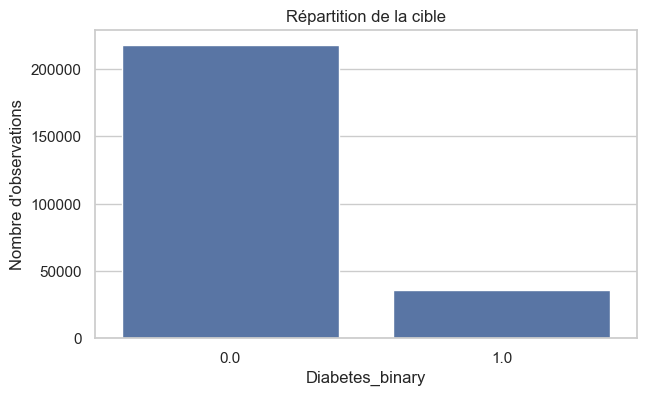

In [7]:
plt.figure(figsize=(7, 4))
sns.countplot(x="Diabetes_binary", data=df)
plt.title("Répartition de la cible")
plt.xlabel("Diabetes_binary")
plt.ylabel("Nombre d'observations")
plt.show()

### Interprétation de la cible

La variable cible est **déséquilibrée** :

- environ **86 %** des individus appartiennent à la classe `0` (non diabétique)
- environ **14 %** appartiennent à la classe `1` (diabétique)

Ce déséquilibre devra être pris en compte lors de la phase de modélisation, car un modèle pourrait être tenté de prédire majoritairement la classe 0 pour obtenir de bonnes performances apparentes.


## 6. Séparation entre variable cible et variables explicatives

On sépare maintenant :

- `y` : la variable cible à prédire
- `X` : les variables explicatives utilisées pour entraîner le modèle


In [8]:
X = df.drop(columns=["Diabetes_binary"])
y = df["Diabetes_binary"]

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Dimensions de X : (253680, 21)
Dimensions de y : (253680,)


## 7. Typage métier des variables

Même si toutes les colonnes sont lues en `float64`, elles n'ont pas toutes la même nature d'un point de vue métier.

On distingue ici trois groupes :

- **Variables binaires** : ne prennent que les valeurs 0 ou 1
- **Variables ordinales** : prennent des valeurs entières codant un ordre
- **Variables numériques** : valeurs quantitatives continues ou discrètes à grande amplitude


In [9]:
binary_cols = [col for col in X.columns if set(X[col].dropna().unique()).issubset({0, 1})]
numeric_cols = ["BMI", "MentHlth", "PhysHlth"]
ordinal_cols = ["GenHlth", "Age", "Education", "Income"]

print("Variables binaires :", binary_cols)
print("\nVariables ordinales :", ordinal_cols)
print("\nVariables numériques :", numeric_cols)

Variables binaires : ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

Variables ordinales : ['GenHlth', 'Age', 'Education', 'Income']

Variables numériques : ['BMI', 'MentHlth', 'PhysHlth']


### Justification du typage

- Les variables comme `HighBP`, `Smoker`, `Stroke` ou `PhysActivity` sont naturellement **binaires**.
- `GenHlth`, `Age`, `Education` et `Income` sont des variables **ordinales** : les valeurs numériques représentent un ordre, mais pas nécessairement une distance métrique parfaite.
- `BMI`, `MentHlth` et `PhysHlth` sont des variables **numériques** qui peuvent être traitées comme quantitatives.

Ce typage sera utile pour les étapes suivantes, notamment pour le choix des visualisations et d'une éventuelle normalisation.


## 8. Vérification des doublons

On cherche maintenant à savoir si certaines lignes apparaissent plusieurs fois dans le dataset.


In [10]:
nb_doublons = df.duplicated().sum()
print("Nombre de doublons :", nb_doublons)

Nombre de doublons : 24206


### Interprétation des doublons

Nous avons identifié **24 206 doublons** dans le dataset.

Dans ce type de base de données, ces doublons peuvent avoir deux explications :

1. **doublons techniques** : la même observation a été répétée par erreur  
2. **doublons réels** : plusieurs individus différents possèdent exactement le même profil de réponses  

Dans une enquête de santé comme le BRFSS, le deuxième cas est possible.  
Cependant, pour ce livrable, nous choisissons de **supprimer les doublons** afin de :

- simplifier le jeu de données
- éviter la surreprésentation de certains profils
- travailler sur une base plus propre pour la suite du projet

Ce choix devra être mentionné dans le rapport, car il s'agit d'une décision méthodologique.


In [11]:
# Suppression des doublons
df_clean = df.drop_duplicates().copy()

print("Dimensions avant suppression :", df.shape)
print("Dimensions après suppression :", df_clean.shape)
print("Nombre de lignes supprimées :", df.shape[0] - df_clean.shape[0])

Dimensions avant suppression : (253680, 22)
Dimensions après suppression : (229474, 22)
Nombre de lignes supprimées : 24206


## 9. Gestion des valeurs manquantes

On vérifie maintenant la présence de valeurs manquantes explicites dans le dataset nettoyé.


In [12]:
missing_values = df_clean.isna().sum()
missing_values

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

### Interprétation des valeurs manquantes

L'analyse montre qu'il n'y a **aucune valeur manquante explicite** dans le dataset.

Aucune imputation n'est donc nécessaire à ce stade.

Il faut toutefois noter qu'en data science, l'absence de valeurs nulles ne signifie pas toujours l'absence de problème : certaines bases utilisent parfois des codes particuliers pour représenter une non-réponse. Ici, les valeurs observées restent cohérentes avec le dictionnaire des variables, donc aucun traitement supplémentaire n'a été retenu.


## 10. Analyse exploratoire quantitative

On étudie maintenant les statistiques du dataset nettoyé.


In [13]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,229474.0,0.152945,0.359936,0.0,0.0,0.0,0.0,1.0
HighBP,229474.0,0.454343,0.497912,0.0,0.0,0.0,1.0,1.0
HighChol,229474.0,0.441640,0.496584,0.0,0.0,0.0,1.0,1.0
CholCheck,229474.0,0.959481,0.197173,0.0,1.0,1.0,1.0,1.0
BMI,229474.0,28.687507,6.789204,12.0,24.0,27.0,32.0,98.0
Smoker,229474.0,0.465800,0.498830,0.0,0.0,0.0,1.0,1.0
Stroke,229474.0,0.044816,0.206899,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,229474.0,0.103336,0.304398,0.0,0.0,0.0,0.0,1.0
PhysActivity,229474.0,0.733042,0.442371,0.0,0.0,1.0,1.0,1.0
Fruits,229474.0,0.612675,0.487140,0.0,0.0,1.0,1.0,1.0


### Lecture quantitative après nettoyage

L'analyse quantitative confirme les constats précédents :

- le `BMI` reste centré autour de 28 avec une dispersion notable
- `MentHlth` et `PhysHlth` conservent une forte asymétrie
- les variables ordinales ont des plages cohérentes avec leur codage
- la cible reste déséquilibrée

Cette étape permet de mieux comprendre les données avant toute modélisation.


## 11. Analyse exploratoire qualitative (EDA visuelle)

L'objectif de cette partie est de visualiser les distributions et certaines relations importantes entre les variables.


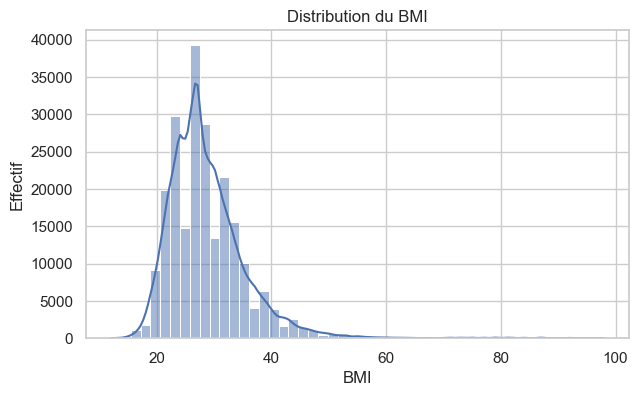

In [14]:
plt.figure(figsize=(7, 4))
sns.histplot(df_clean["BMI"], bins=50, kde=True)
plt.title("Distribution du BMI")
plt.xlabel("BMI")
plt.ylabel("Effectif")
plt.show()

### Interprétation du BMI
La distribution du BMI montre une forte concentration des individus entre 20 et 35, ce qui correspond à une population majoritairement en surpoids.

La distribution est asymétrique à droite, avec une longue queue indiquant la présence de valeurs élevées.

On observe également des valeurs extrêmes dépassant 60, voire 90. Ces valeurs peuvent correspondre à des cas d'obésité sévère ou à des anomalies dans les données.

Le BMI étant un facteur de risque majeur du diabète, cette variable est particulièrement pertinente pour la suite du projet.

La présence d'outliers est conservée volontairement afin de ne pas perdre d'information potentiellement utile.

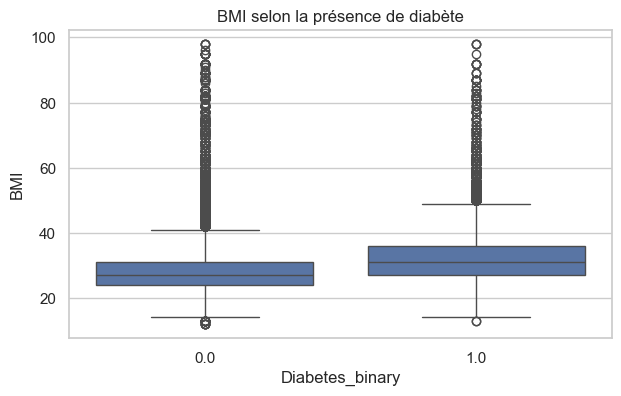

In [15]:
plt.figure(figsize=(7, 4))
sns.boxplot(x="Diabetes_binary", y="BMI", data=df_clean)
plt.title("BMI selon la présence de diabète")
plt.xlabel("Diabetes_binary")
plt.ylabel("BMI")
plt.show()

### Interprétation – BMI selon la présence de diabète

Le boxplot montre une différence nette entre les deux groupes :

- les individus diabétiques ont en moyenne un BMI plus élevé
- la médiane du BMI est clairement supérieure pour la classe 1

On observe également une dispersion plus importante chez les personnes diabétiques, ainsi qu'un nombre élevé de valeurs extrêmes.

Ces observations confirment que le BMI est fortement lié au diabète et constitue une variable explicative importante pour le modèle.

La présence d'outliers dans les deux groupes suggère que certaines situations extrêmes doivent être prises en compte plutôt qu'exclues.

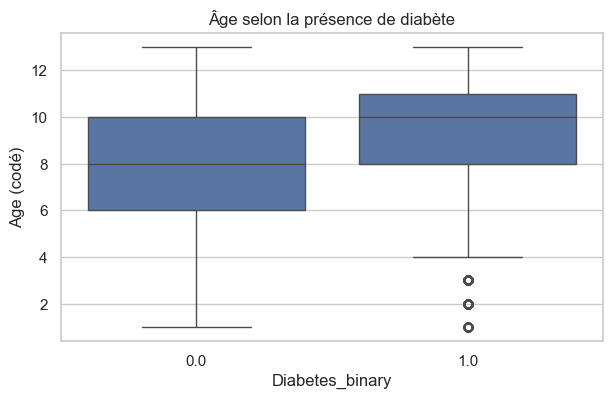

In [16]:
plt.figure(figsize=(7, 4))
sns.boxplot(x="Diabetes_binary", y="Age", data=df_clean)
plt.title("Âge selon la présence de diabète")
plt.xlabel("Diabetes_binary")
plt.ylabel("Age (codé)")
plt.show()

### Interprétation – Âge selon la présence de diabète

Le boxplot montre que les individus diabétiques appartiennent globalement à des catégories d'âge plus élevées.

La médiane de l'âge est plus importante pour la classe 1, ce qui indique que le risque de diabète augmente avec l'âge.

Même si la variable `Age` est codée de manière ordinalisée, la tendance reste claire et cohérente avec les connaissances médicales.

Cette variable apparaît donc comme un facteur important dans la prédiction du diabète.

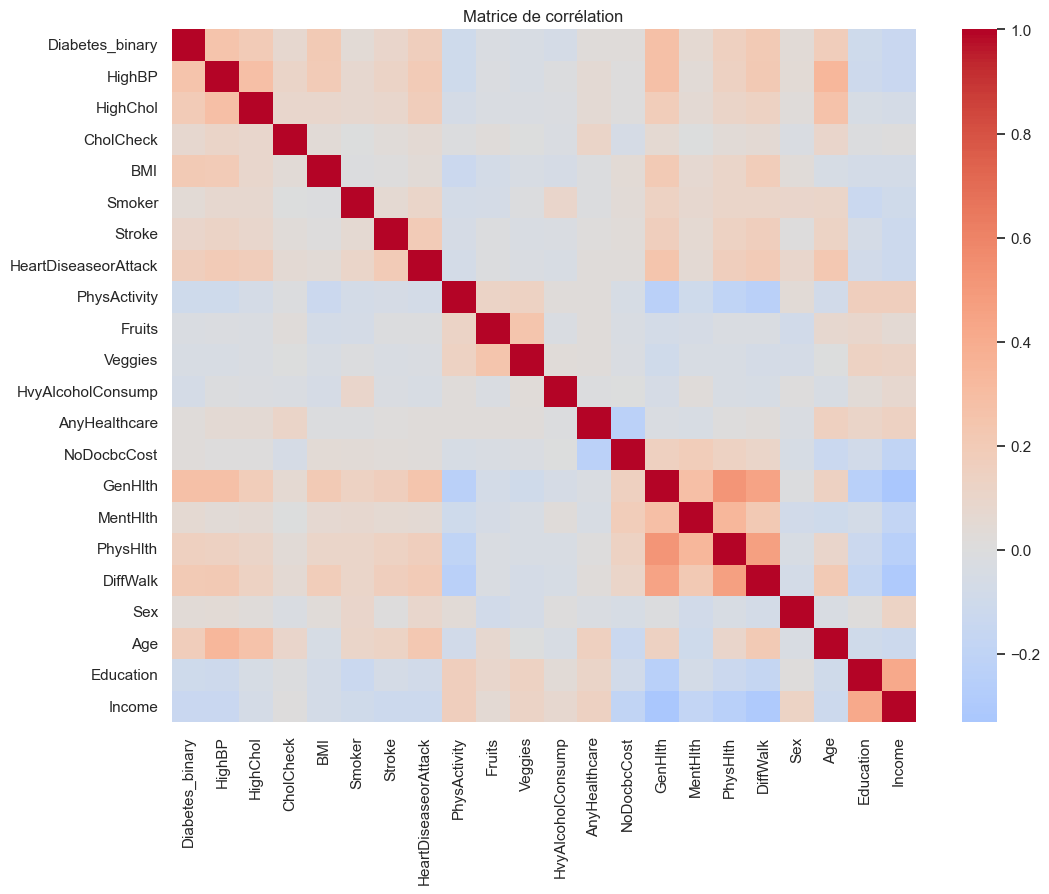

In [17]:
plt.figure(figsize=(12, 9))
corr = df_clean.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation")
plt.show()

### Interprétation – Matrice de corrélation

La matrice de corrélation permet d'observer les relations linéaires entre les variables.

On constate que la majorité des corrélations sont faibles à modérées, ce qui est attendu dans des données issues du réel.

Cependant, certaines variables présentent des corrélations positives avec la variable cible, notamment :

- HighBP (hypertension)
- BMI
- GenHlth (santé générale)
- DiffWalk (difficulté à marcher)
- Age

Ces variables sont donc potentiellement importantes pour la prédiction du diabète.

Par ailleurs, aucune corrélation extrêmement forte entre les variables explicatives n’est observée, ce qui limite les problèmes de multicolinéarité.

Cela signifie que les variables apportent des informations complémentaires au modèle.

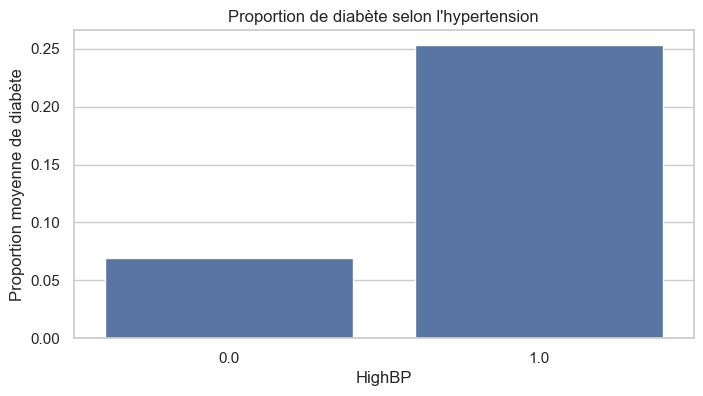

In [18]:
plt.figure(figsize=(8, 4))
sns.barplot(x="HighBP", y="Diabetes_binary", data=df_clean, estimator=np.mean, errorbar=None)
plt.title("Proportion de diabète selon l'hypertension")
plt.xlabel("HighBP")
plt.ylabel("Proportion moyenne de diabète")
plt.show()

### Interprétation – Diabète selon l'hypertension

Le graphique montre une différence très marquée entre les deux groupes :

- les individus sans hypertension ont une faible proportion de diabète (~7%)
- les individus avec hypertension ont une proportion beaucoup plus élevée (~25%)

Cela indique une forte association entre l’hypertension et le diabète.

Cette variable apparaît donc comme un facteur prédictif très pertinent.

Ce résultat est cohérent avec les connaissances médicales, où l’hypertension est souvent associée à des pathologies métaboliques comme le diabète.

## 12. Analyse des valeurs aberrantes (outliers)

Suite aux analyses exploratoires précédentes, notamment l'étude des distributions et des boxplots, il apparaît que certaines variables présentent des valeurs extrêmes. C'est particulièrement le cas de la variable **BMI**, pour laquelle des valeurs très élevées ont été observées.

Ces valeurs aberrantes (outliers) peuvent correspondre à :
- des cas réels (ex : obésité sévère)
- des erreurs de mesure ou de saisie
- des situations atypiques mais pertinentes

Afin de mieux identifier ces valeurs, nous utilisons une méthode statistique classique basée sur l’**écart interquartile (IQR)**.

### Méthode IQR

La méthode IQR consiste à définir des bornes à partir des quartiles :

- Q1 : 1er quartile (25%)
- Q3 : 3ème quartile (75%)
- IQR = Q3 - Q1

Les valeurs sont considérées comme aberrantes si elles sont :
- inférieures à : Q1 - 1.5 × IQR
- supérieures à : Q3 + 1.5 × IQR

### Détection des outliers sur le BMI

In [22]:
Q1 = df_clean["BMI"].quantile(0.25)
Q3 = df_clean["BMI"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_bmi = df_clean[(df_clean["BMI"] < lower_bound) | (df_clean["BMI"] > upper_bound)]

print("Nombre d'outliers BMI :", outliers_bmi.shape[0])
print("Bornes inférieure et supérieure :", lower_bound, upper_bound)

Nombre d'outliers BMI : 5638
Bornes inférieure et supérieure : 12.0 44.0


### Interprétation des résultats

L'analyse confirme la présence d'un nombre significatif de valeurs aberrantes sur la variable BMI.

Ces valeurs extrêmes sont cohérentes avec les observations faites précédemment sur les distributions et les boxplots. Elles traduisent une dispersion importante de la variable, avec certains individus présentant des valeurs très élevées.

### Choix méthodologique

Dans le cadre de ce projet, nous faisons le choix de **ne pas supprimer ces valeurs aberrantes** pour plusieurs raisons :

- le dataset provient d’une enquête réelle, donc ces valeurs peuvent correspondre à des situations réelles
- les outliers peuvent contenir une information importante pour la prédiction
- leur suppression pourrait introduire un biais dans les données

Une gestion plus avancée des valeurs aberrantes (par exemple via des techniques de transformation ou de clipping) pourra être envisagée ultérieurement si nécessaire, notamment lors de la phase de modélisation.

Ainsi, les outliers sont **identifiés et analysés, mais conservés dans le dataset** pour la suite du projet.

## 13. Préparation du dataset final pour le split

On travaille à partir du dataset nettoyé (`df_clean`), puis on refait la séparation entre la cible et les variables explicatives.


In [19]:
X = df_clean.drop(columns=["Diabetes_binary"])
y = df_clean["Diabetes_binary"]

print("Dimensions de X après nettoyage :", X.shape)
print("Dimensions de y après nettoyage :", y.shape)

Dimensions de X après nettoyage : (229474, 21)
Dimensions de y après nettoyage : (229474,)


## 14. Scission du dataset en train / validation / test

Nous avons choisi une répartition :

- **70 %** pour l'entraînement
- **15 %** pour la validation
- **15 %** pour le test

### Justification de ce choix

Cette répartition est classique et pertinente car elle permet de :

- garder suffisamment de données pour entraîner le modèle
- disposer d'un jeu de validation pour comparer plusieurs approches
- conserver un jeu de test indépendant pour l'évaluation finale

Nous utilisons également une **stratification sur la variable cible** afin de conserver la même proportion de classes dans chaque sous-ensemble.  
C'est particulièrement important ici à cause du déséquilibre entre les classes.


In [20]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Dimensions du jeu d'entraînement :", X_train.shape)
print("Dimensions du jeu de validation :", X_val.shape)
print("Dimensions du jeu de test :", X_test.shape)

Dimensions du jeu d'entraînement : (160631, 21)
Dimensions du jeu de validation : (34421, 21)
Dimensions du jeu de test : (34422, 21)


In [21]:
print("Répartition de la cible dans y_train :")
print(y_train.value_counts(normalize=True))

print("\nRépartition de la cible dans y_val :")
print(y_val.value_counts(normalize=True))

print("\nRépartition de la cible dans y_test :")
print(y_test.value_counts(normalize=True))

Répartition de la cible dans y_train :
Diabetes_binary
0.0    0.847053
1.0    0.152947
Name: proportion, dtype: float64

Répartition de la cible dans y_val :
Diabetes_binary
0.0    0.84707
1.0    0.15293
Name: proportion, dtype: float64

Répartition de la cible dans y_test :
Diabetes_binary
0.0    0.847045
1.0    0.152955
Name: proportion, dtype: float64


### Vérification de la stratification

Les proportions de classes restent très proches entre les jeux d'entraînement, de validation et de test.

Cela confirme que la stratification a bien fonctionné et garantit une répartition cohérente des classes pour la suite du projet.


## 15. Choix d'une méthode de normalisation

Dans le cadre de ce projet, l’objectif final est de développer un modèle de **deep learning**, et plus précisément un **réseau de neurones**. Or, ce type de modèle est sensible à l’échelle des variables d’entrée. Une normalisation est donc nécessaire afin de faciliter l’apprentissage du modèle et de stabiliser l’optimisation.

Plusieurs méthodes de normalisation peuvent être envisagées :

- **StandardScaler** : centre les données autour de 0 avec un écart-type égal à 1
- **MinMaxScaler** : ramène les données dans un intervalle borné, généralement entre 0 et 1
- **RobustScaler** : utilise la médiane et l’écart interquartile, ce qui le rend plus robuste aux valeurs aberrantes

Dans ce livrable, nous choisissons d’utiliser **StandardScaler**.

### Justification du choix

Le **StandardScaler** a été retenu pour plusieurs raisons :

- il est très largement utilisé en machine learning et en deep learning
- il est bien adapté aux réseaux de neurones
- il permet de mettre les variables sur une échelle comparable
- il facilite la convergence pendant l’entraînement
- il constitue une méthode simple, robuste et facile à justifier dans une première approche

Nous avons également envisagé l’utilisation de **RobustScaler**, qui peut être intéressant en présence de valeurs aberrantes, notamment sur la variable BMI. Cependant, dans cette première étape du projet, nous retenons **StandardScaler comme méthode de référence**, car il constitue un choix classique et pertinent pour un premier pipeline de modélisation.

Si les résultats du réseau de neurones montrent par la suite une sensibilité importante aux valeurs extrêmes, une comparaison avec **RobustScaler** pourra être envisagée.


In [23]:
from sklearn.preprocessing import StandardScaler

# Colonnes à normaliser
cols_a_normaliser = numeric_cols + ordinal_cols

# Copies des jeux de données
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

# Initialisation du scaler
scaler = StandardScaler()

# Apprentissage sur le train uniquement
X_train_scaled[cols_a_normaliser] = scaler.fit_transform(X_train[cols_a_normaliser])

# Application sur validation et test
X_val_scaled[cols_a_normaliser] = scaler.transform(X_val[cols_a_normaliser])
X_test_scaled[cols_a_normaliser] = scaler.transform(X_test[cols_a_normaliser])

print("Normalisation appliquée avec StandardScaler.")

Normalisation appliquée avec StandardScaler.


## 16. Sauvegarde des jeux de données préparés

On sauvegarde maintenant les jeux de données nettoyés et découpés.

Cela permet :

- de conserver une version stable du prétraitement
- de faciliter la reproductibilité
- de préparer proprement les prochains livrables


In [24]:
train_clean = X_train.copy()
train_clean["Diabetes_binary"] = y_train.values

val_clean = X_val.copy()
val_clean["Diabetes_binary"] = y_val.values

test_clean = X_test.copy()
test_clean["Diabetes_binary"] = y_test.values

train_clean.to_csv("train_clean.csv", index=False)
val_clean.to_csv("val_clean.csv", index=False)
test_clean.to_csv("test_clean.csv", index=False)

print("Fichiers sauvegardés : train_clean.csv, val_clean.csv, test_clean.csv")

Fichiers sauvegardés : train_clean.csv, val_clean.csv, test_clean.csv


## 17. Conclusion

Ce premier livrable a permis de poser des bases solides pour la suite du projet de prédiction du diabète. À travers une démarche structurée, nous avons d’abord chargé et analysé le dataset afin d’en comprendre la structure, la nature des variables et la distribution de la variable cible. Cette phase d’exploration a mis en évidence un déséquilibre de classes ainsi que la présence de valeurs extrêmes, notamment sur la variable BMI, qui ont été analysées et conservées dans une logique métier.

Le dataset a ensuite été nettoyé, notamment par la suppression des doublons, tout en vérifiant l’absence de valeurs manquantes. Une analyse exploratoire approfondie, à la fois quantitative et visuelle, a permis d’identifier plusieurs relations pertinentes entre certaines variables de santé et la présence du diabète.

Dans un souci de rigueur méthodologique, les données ont été séparées en jeux d’entraînement, de validation et de test en utilisant une stratification sur la variable cible, garantissant ainsi une répartition cohérente des classes. Par ailleurs, une réflexion a été menée sur la normalisation des données, avec le choix du StandardScaler comme méthode de référence pour la suite du projet, notamment en vue de l’utilisation de modèles de deep learning.

Enfin, les jeux de données préparés ont été sauvegardés afin d’assurer la reproductibilité des étapes de prétraitement et de faciliter les prochaines phases du projet. Ce travail constitue une étape essentielle, permettant d’aborder dans de bonnes conditions la phase de modélisation et d’optimisation des performances du modèle.

## 18. Pistes pour la suite

Les prochaines étapes du projet pourront inclure :

- la comparaison de plusieurs modèles de classification
- la gestion du déséquilibre de classes
- l'étude de métriques adaptées comme le **ROC AUC**
- l'optimisation des hyperparamètres
- l'analyse de l'importance des variables
